<a href="https://colab.research.google.com/github/francji1/01RAD/blob/main/code/01RAD_Ex01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01RAD - Exercise 01: Simple Linear Regression

We revisit Galton's father-son height data to practise two things: small-sample $t$-tests as a warm-up, and the mechanics of the simple linear regression model from Lecture 1,

$$Y_i = \beta_0 + \beta_1 x_i + e_i, \qquad i = 1, \dots, n, \qquad (\ast)$$

where $x_i$ is the explanatory variable, $Y_i$ the response and $e_1, \dots, e_n$ are independent random errors with $\mathrm{E}\, e_i = 0$ and $\mathrm{Var}(e_i) = \sigma^2$. We fit the line by least squares in three equivalent ways, compute the residuals and the estimates of $\sigma^2$, and preview the standard errors of the coefficients that Lecture 2 will derive.

## Learning goals
- Refresh exploratory summaries for a bivariate dataset.
- Recap one-sample and paired $t$-tests using both manual formulas and `scipy` helpers.
- Compute the least squares estimates $\widehat{\beta}_0, \widehat{\beta}_1$ step by step and confirm that several computational routes agree.
- Distinguish the maximum likelihood estimate $\widehat{\sigma}^2$ from the unbiased estimate $s_n^2$ of the error variance.
- Preview Lecture 2: standard errors of $\widehat{\beta}_0, \widehat{\beta}_1$, the `statsmodels` summary table and the lecture's speed-of-sound example.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.precision', 3)
pd.set_option('display.float_format', '{:.3f}'.format)

## 2. Load and inspect the dataset
The file `fsdata.csv` contains Galton's measurements (in inches) for 1,078 father-son pairs. The first column of the file is just the R row index, so we use it as the DataFrame index.

In [2]:
url_fsdata = 'https://raw.githubusercontent.com/francji1/01RAD/main/data/fsdata.csv'
fsdata = pd.read_csv(url_fsdata, index_col=0)
print(f'Rows: {fsdata.shape[0]}, columns: {fsdata.shape[1]}')
fsdata.head()

Rows: 1078, columns: 2


,father,son
1,65.049,59.778
2,63.251,63.214
3,64.955,63.342
4,65.752,62.792
5,61.137,64.281


### Structural overview

In [3]:
fsdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1078 entries, 1 to 1078
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   father  1078 non-null   float64
 1   son     1078 non-null   float64
dtypes: float64(2)
memory usage: 25.3 KB


In [4]:
fsdata.describe().T

,count,mean,std,min,25%,50%,75%,max
father,1078.000,67.687,2.745,59.008,65.788,67.767,69.603,75.434
son,1078.000,68.684,2.815,58.507,66.931,68.616,70.466,78.365


## 3. Exploring the distributions
Visual checks help confirm that the marginal distributions look roughly symmetric and that father and son heights are positively related.

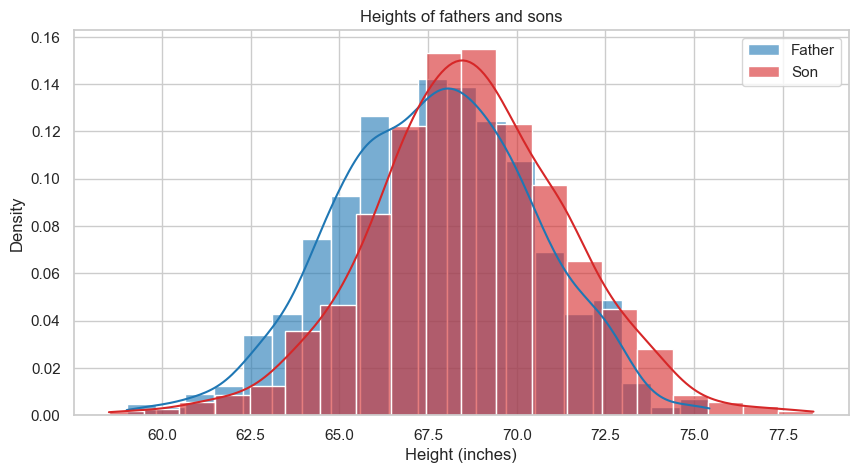

In [5]:
plt.figure(figsize=(10, 5))

sns.histplot(fsdata, x='father', bins=20, color='#1f77b4', kde=True, stat='density', alpha=0.6, label='Father')
sns.histplot(fsdata, x='son', bins=20, color='#d62728', kde=True, stat='density', alpha=0.6, label='Son')

plt.title('Heights of fathers and sons')
plt.xlabel('Height (inches)')
plt.ylabel('Density')
plt.legend()
plt.show()

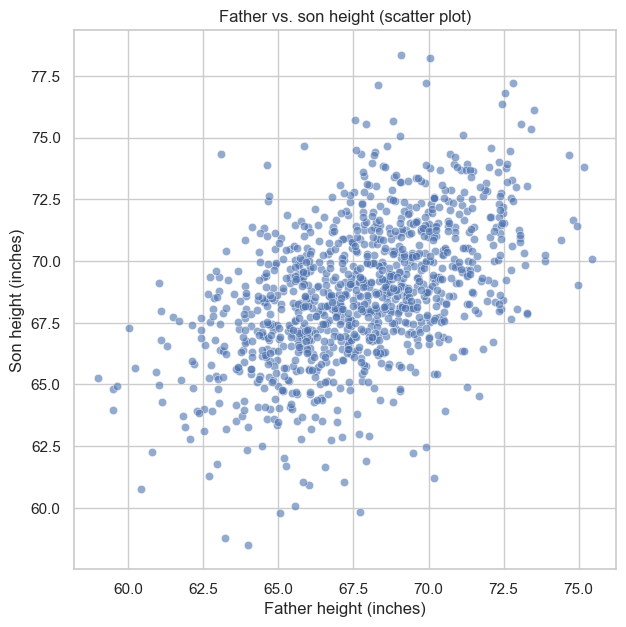

In [6]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=fsdata, x='father', y='son', alpha=0.6)
plt.title('Father vs. son height (scatter plot)')
plt.xlabel('Father height (inches)')
plt.ylabel('Son height (inches)')
plt.show()

## 4. Recap: $t$-tests
Two classical tests from your earlier statistics course, useful as a warm-up before regression.
1. A *paired* $t$-test to compare father and son means (the observations are naturally paired by family).
2. A one-sample $t$-test to check whether the average son height exceeds 67 inches.

Both are shown twice: first via manual formulas, then with `scipy` for confirmation.

### 4.1 Paired $t$-test (sons vs fathers)

In [7]:
diff = fsdata['son'] - fsdata['father']
mean_diff = diff.mean()
sd_diff = diff.std(ddof=1)
n = len(diff)

standard_error = sd_diff / np.sqrt(n)
t_statistic = mean_diff / standard_error
degrees_of_freedom = n - 1

p_value_two_sided = 2 * (1 - stats.t.cdf(abs(t_statistic), df=degrees_of_freedom))

print(f"Mean difference (son - father): {mean_diff:.3f} inches")
print(f"t statistic: {t_statistic:.3f}, df: {degrees_of_freedom}")
print(f"Two-sided p-value: {p_value_two_sided:.4f}")

Mean difference (son - father): 0.997 inches
t statistic: 11.789, df: 1077
Two-sided p-value: 0.0000


In [8]:
scipy_result = stats.ttest_rel(fsdata['son'], fsdata['father'])
print(scipy_result)

TtestResult(statistic=11.788549038237012, pvalue=2.957226369228171e-30, df=1077)


### 4.2 One-sample $t$-test (is the mean son height > 67 inches?)

In [9]:
mu_0 = 67
sons = fsdata['son']
mean_son = sons.mean()
std_son = sons.std(ddof=1)
n = len(sons)

standard_error = std_son / np.sqrt(n)
t_statistic = (mean_son - mu_0) / standard_error
p_value_one_sided = 1 - stats.t.cdf(t_statistic, df=n - 1)

print(f"Sample mean: {mean_son:.3f} inches")
print(f"t statistic: {t_statistic:.3f}, df: {n - 1}")
print(f"One-sided p-value (H1: mean > 67): {p_value_one_sided:.4f}")

Sample mean: 68.684 inches
t statistic: 19.644, df: 1077
One-sided p-value (H1: mean > 67): 0.0000


In [10]:
scipy_result = stats.ttest_1samp(sons, popmean=mu_0, alternative='greater')
print(scipy_result)

TtestResult(statistic=19.644323273595266, pvalue=5.6639323832923115e-74, df=1077)


## 5. Least squares estimates by hand
Lecture 1 estimates $\beta_0, \beta_1$ in model $(\ast)$ by minimising the sum of squared vertical deviations

$$S(\beta_0, \beta_1) = \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2 .$$

The minimisers are the **least squares estimates** (LSE); for normally distributed errors they coincide with the maximum likelihood estimates:

$$\widehat{\beta}_1 = \frac{\sum_{i=1}^{n} x_i y_i - n\,\overline{x}\,\overline{y}}{\sum_{i=1}^{n} x_i^2 - n\,\overline{x}^2}
 = \frac{S_{xy}}{S_{xx}}, \qquad \widehat{\beta}_0 = \overline{y} - \widehat{\beta}_1 \overline{x},$$

with $S_{xx} = \sum_i (x_i - \overline{x})^2$ and $S_{xy} = \sum_i (x_i - \overline{x})(y_i - \overline{y})$.

We compute the estimates three different ways and show that they agree:
1. directly from the sums (both forms of the formula above),
2. using the covariance/variance relationship,
3. by solving the least squares problem numerically (`np.linalg.lstsq`).

In [11]:
Y = fsdata['son'].to_numpy()      # response y_i
X = fsdata['father'].to_numpy()   # explanatory variable x_i
n = len(X)

x_mean = X.mean()
y_mean = Y.mean()

# lecture form of the slope formula
beta1_lecture = (np.sum(X * Y) - n * x_mean * y_mean) / (np.sum(X ** 2) - n * x_mean ** 2)

# centred form: S_xy / S_xx
S_xy = np.sum((X - x_mean) * (Y - y_mean))
S_xx = np.sum((X - x_mean) ** 2)
beta1_from_sums = S_xy / S_xx
beta0_from_sums = y_mean - beta1_from_sums * x_mean

print(f"beta1_hat, lecture form : {beta1_lecture:.6f}")
print(f"beta1_hat, S_xy / S_xx  : {beta1_from_sums:.6f}")
print(f"beta0_hat               : {beta0_from_sums:.6f}")

beta1_hat, lecture form : 0.514093
beta1_hat, S_xy / S_xx  : 0.514093
beta0_hat               : 33.886604


In [12]:
# Covariance / variance formulation
cov_xy = np.cov(X, Y, ddof=1)[0, 1]
var_x = np.var(X, ddof=1)

beta1_from_cov = cov_xy / var_x
beta0_from_cov = y_mean - beta1_from_cov * x_mean

print(f"Beta1 (slope) from covariance: {beta1_from_cov:.4f}")
print(f"Beta0 (intercept) from covariance: {beta0_from_cov:.4f}")

Beta1 (slope) from covariance: 0.5141
Beta0 (intercept) from covariance: 33.8866


In [13]:
# Linear algebra / least squares solution
X_design = np.column_stack((np.ones_like(X), X))
beta_hat, *_ = np.linalg.lstsq(X_design, Y, rcond=None)

beta0_lstsq, beta1_lstsq = beta_hat
print(f"Beta0 from lstsq: {beta0_lstsq:.4f}")
print(f"Beta1 from lstsq: {beta1_lstsq:.4f}")

Beta0 from lstsq: 33.8866
Beta1 from lstsq: 0.5141


In [14]:
comparison = pd.DataFrame({
    'approach': ['normal equations', 'covariance ratio', 'least squares'],
    'beta0': [beta0_from_sums, beta0_from_cov, beta0_lstsq],
    'beta1': [beta1_from_sums, beta1_from_cov, beta1_lstsq]
})
comparison

,approach,beta0,beta1
0,normal equations,33.887,0.514
1,covariance ratio,33.887,0.514
2,least squares,33.887,0.514


## 6. Fitted values, residuals and the estimate of $\sigma^2$
With the estimates in hand we obtain the **fitted values** (predictions of $\mathrm{E}\,Y_i$) and the **residuals**

$$\widehat{y}_i = \widehat{\beta}_0 + \widehat{\beta}_1 x_i, \qquad \widehat{e}_i = y_i - \widehat{y}_i, \qquad SSE = \sum_{i=1}^{n} \widehat{e}_i^{\,2}.$$

Lecture 1 gives two estimates of the error variance:

- the maximum likelihood estimate $\widehat{\sigma}^2 = \dfrac{1}{n} SSE$, which is biased,
- the unbiased estimate $s_n^2 = \dfrac{1}{n-2} SSE$, which is the one used in practice (`Residual standard error` in R, `scale` in `statsmodels`). Its square root $s_n$ is called the residual standard error; note that $s_n$ itself is *not* an unbiased estimate of $\sigma$.

The residuals of a least squares fit with intercept always satisfy the normal equations $\sum_i \widehat{e}_i = 0$ and $\sum_i x_i \widehat{e}_i = 0$; we verify this numerically.

In [15]:
b0_hat, b1_hat = beta0_from_sums, beta1_from_sums

y_hat = b0_hat + b1_hat * X
e_hat = Y - y_hat
SSE = np.sum(e_hat ** 2)

sigma2_mle = SSE / n          # biased MLE
s_n2 = SSE / (n - 2)          # unbiased estimate of sigma^2
s_n = np.sqrt(s_n2)           # residual standard error

print(f"SSE                 : {SSE:.3f}")
print(f"sigma^2 (MLE, /n)   : {sigma2_mle:.4f}")
print(f"s_n^2 (/(n-2))      : {s_n2:.4f}")
print(f"s_n                 : {s_n:.4f}")
print()
print(f"sum of residuals        : {np.sum(e_hat):.2e}   (should be 0)")
print(f"sum of x_i * residuals  : {np.sum(X * e_hat):.2e}   (should be 0)")

SSE                 : 6388.001
sigma^2 (MLE, /n)   : 5.9258
s_n^2 (/(n-2))      : 5.9368
s_n                 : 2.4366

sum of residuals        : 1.89e-11   (should be 0)
sum of x_i * residuals  : 1.28e-09   (should be 0)


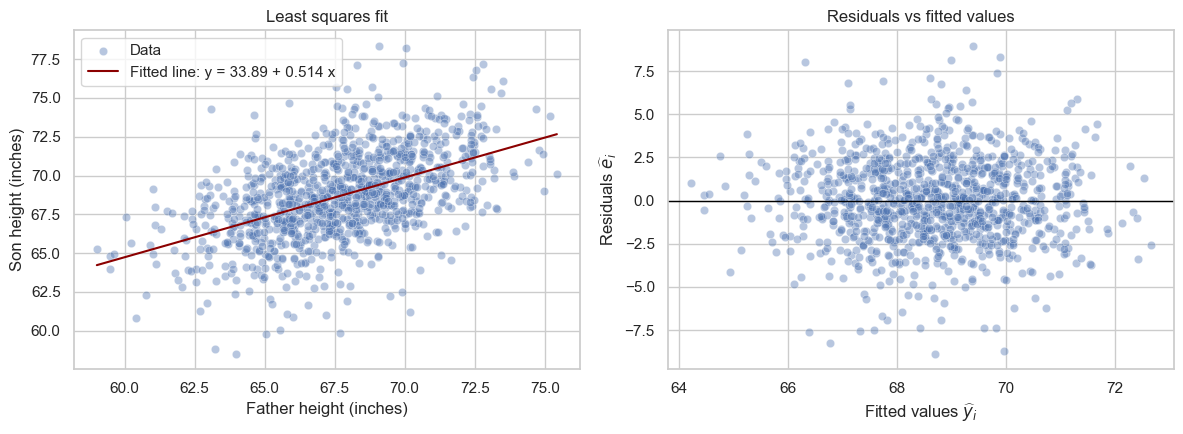

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(x=X, y=Y, alpha=0.4, ax=axes[0], label='Data')
x_line = np.linspace(X.min(), X.max(), 100)
axes[0].plot(x_line, b0_hat + b1_hat * x_line, color='darkred',
             label=f'Fitted line: y = {b0_hat:.2f} + {b1_hat:.3f} x')
axes[0].set_xlabel('Father height (inches)')
axes[0].set_ylabel('Son height (inches)')
axes[0].set_title('Least squares fit')
axes[0].legend()

sns.scatterplot(x=y_hat, y=e_hat, alpha=0.4, ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Fitted values $\\widehat{y}_i$')
axes[1].set_ylabel('Residuals $\\widehat{e}_i$')
axes[1].set_title('Residuals vs fitted values')

plt.tight_layout()
plt.show()

## 7. Preview of Lecture 2: standard errors of $\widehat{\beta}_0, \widehat{\beta}_1$
Lecture 2 shows that the least squares estimates are unbiased and that

$$\mathrm{Var}(\widehat{\beta}_1) = \frac{\sigma^2}{S_{xx}}, \qquad
  \mathrm{Var}(\widehat{\beta}_0) = \sigma^2 \left( \frac{1}{n} + \frac{\overline{x}^2}{S_{xx}} \right).$$

Replacing the unknown $\sigma^2$ by $s_n^2$ gives the estimated variances, and their square roots are the **standard errors** of the estimates,

$$\widehat{\sigma}(\widehat{\beta}_1) = \frac{s_n}{\sqrt{S_{xx}}}, \qquad
  \widehat{\sigma}(\widehat{\beta}_0) = s_n \sqrt{\frac{1}{n} + \frac{\overline{x}^2}{S_{xx}}} .$$

For now just compute them; confidence intervals and tests built from these quantities come next week.

In [17]:
var_b1_hat = s_n2 / S_xx
var_b0_hat = s_n2 * (1 / n + x_mean ** 2 / S_xx)

se_b1 = np.sqrt(var_b1_hat)
se_b0 = np.sqrt(var_b0_hat)

pd.Series({
    's_n (residual standard error)': s_n,
    'estimated Var(beta1_hat)': var_b1_hat,
    'SE(beta1_hat)': se_b1,
    'estimated Var(beta0_hat)': var_b0_hat,
    'SE(beta0_hat)': se_b0,
}).to_frame('value')

,value
s_n (residual standard error),2.437
estimated Var(beta1_hat),0.001
SE(beta1_hat),0.027
estimated Var(beta0_hat),3.358
SE(beta0_hat),1.832


## 8. Regression through the origin: the normal equations in matrix form
Writing the model with the design matrix $\mathbf{X}$ (a column of ones and the column of $x_i$), the least squares estimate solves the normal equations $\mathbf{X}^\top \mathbf{X}\, \widehat{\boldsymbol{\beta}} = \mathbf{X}^\top \mathbf{y}$. For the model *without intercept*, $Y_i = \beta_1 x_i + e_i$, the design matrix has a single column and the system is $1 \times 1$. This matrix view is the bridge to multiple regression in later lectures.

In [18]:
IX = np.column_stack([np.ones(n), X])   # design matrix with intercept
X_no_const = X.reshape(-1, 1)            # design matrix without intercept

beta_hat_no_const = np.linalg.solve(X_no_const.T @ X_no_const, X_no_const.T @ Y)
beta_hat_with_const = np.linalg.solve(IX.T @ IX, IX.T @ Y)

pd.DataFrame({
    'model': ['no intercept', 'with intercept'],
    'beta0': [0.0, beta_hat_with_const[0]],
    'beta1': [beta_hat_no_const[0], beta_hat_with_const[1]]
})

,model,beta0,beta1
0,no intercept,0.000,1.014
1,with intercept,33.887,0.514


## 9. The same fit with `statsmodels`
`statsmodels` will be our workhorse for inference. Its summary table has the same layout as R's `summary(lm(...))` used in the lectures: coefficients, their standard errors, $t$ values and $p$-values, followed by the residual standard error $s_n$ (`scale` is $s_n^2$). Check that the coefficients and the standard errors agree with our manual computation.

In [19]:
model_no_intercept = sm.OLS(Y, X_no_const).fit()
model_with_intercept = sm.OLS(Y, sm.add_constant(X)).fit()

pd.DataFrame({
    'quantity': ['beta0_hat', 'beta1_hat', 'SE(beta0_hat)', 'SE(beta1_hat)', 's_n'],
    'manual': [b0_hat, b1_hat, se_b0, se_b1, s_n],
    'statsmodels': [model_with_intercept.params[0], model_with_intercept.params[1],
                    model_with_intercept.bse[0], model_with_intercept.bse[1],
                    np.sqrt(model_with_intercept.scale)]
})

,quantity,manual,statsmodels
0,beta0_hat,33.887,33.887
1,beta1_hat,0.514,0.514
2,SE(beta0_hat),1.832,1.832
3,SE(beta1_hat),0.027,0.027
4,s_n,2.437,2.437


In [20]:
print(model_with_intercept.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     361.2
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           1.12e-69
Time:                        21:36:51   Log-Likelihood:                -2488.7
No. Observations:                1078   AIC:                             4981.
Df Residuals:                    1076   BIC:                             4991.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8866      1.832     18.493      0.0

In [21]:
results_preview = pd.DataFrame({
    'model': ['no intercept', 'with intercept'],
    'beta0': [0.0, model_with_intercept.params[0]],
    'beta1': [model_no_intercept.params[0], model_with_intercept.params[1]],
    'R_squared': [model_no_intercept.rsquared, model_with_intercept.rsquared]
})
results_preview

,model,beta0,beta1,R_squared
0,no intercept,0.000,1.014,0.998
1,with intercept,33.887,0.514,0.251


### Comparing the two fitted lines
Notice how the line forced through the origin (blue) differs from the line with a fitted intercept (red), especially for shorter fathers. Whether the intercept is needed is a question we will answer with a test in Lecture 2. Do not compare the two models by $R^2$: for a model without intercept `statsmodels` (like R) defines $R^2$ differently, so the values are not comparable.

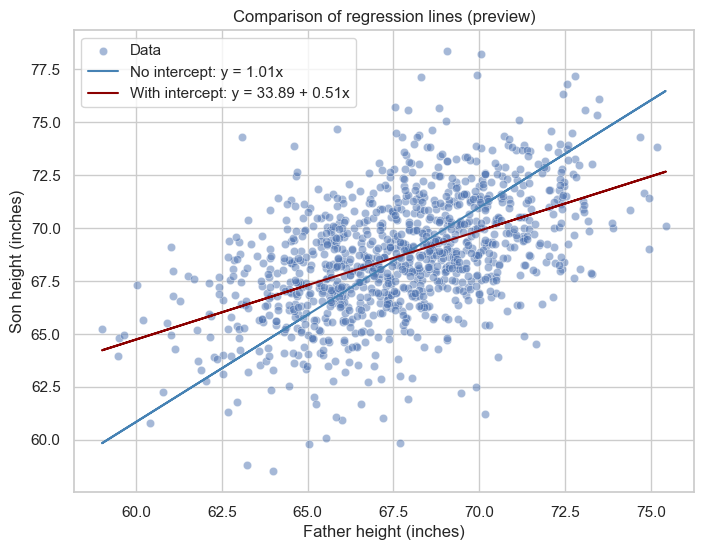

In [22]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X, y=Y, alpha=0.5, label='Data')
plt.plot(X, X * beta_hat_no_const[0], color='steelblue', label=f'No intercept: y = {beta_hat_no_const[0]:.2f}x')
plt.plot(X, model_with_intercept.params[0] + model_with_intercept.params[1] * X,
         color='darkred', label=f'With intercept: y = {model_with_intercept.params[0]:.2f} + {model_with_intercept.params[1]:.2f}x')
plt.xlabel('Father height (inches)')
plt.ylabel('Son height (inches)')
plt.title('Comparison of regression lines (preview)')
plt.legend()
plt.show()


### Optional challenge: what happens with outliers?
Try adding a couple of extreme points and re-running the fits above. How sensitive are the coefficients? A code scaffold is provided if you want to experiment.

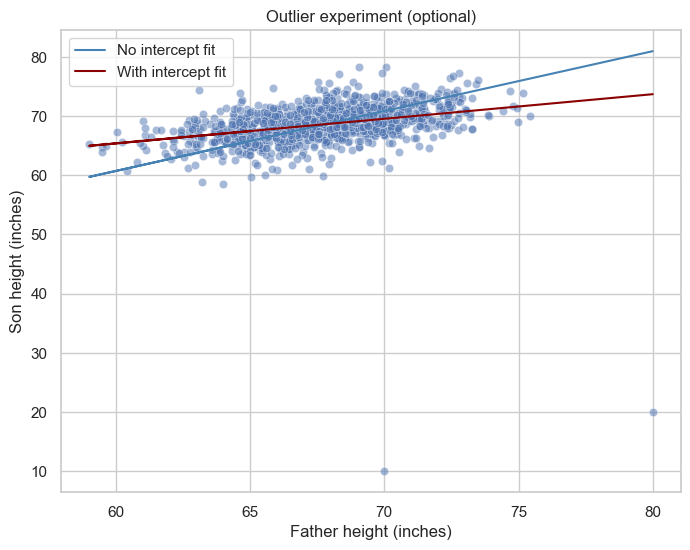

,model,beta0,beta1
0,no intercept (outliers),0.000,1.012
1,with intercept (outliers),40.445,0.416


In [23]:
fsdata_outliers = fsdata.copy()
outliers = pd.DataFrame({'father': [70, 80], 'son': [10, 20]})
fsdata_outliers = pd.concat([fsdata_outliers, outliers], ignore_index=True)

model_no_intercept_out = smf.ols('son ~ -1 + father', data=fsdata_outliers).fit()
model_with_intercept_out = smf.ols('son ~ father', data=fsdata_outliers).fit()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=fsdata_outliers, x='father', y='son', alpha=0.5)
plt.plot(fsdata_outliers['father'], model_no_intercept_out.fittedvalues, color='steelblue', label='No intercept fit')
plt.plot(fsdata_outliers['father'], model_with_intercept_out.fittedvalues, color='darkred', label='With intercept fit')
plt.xlabel('Father height (inches)')
plt.ylabel('Son height (inches)')
plt.title('Outlier experiment (optional)')
plt.legend()
plt.show()

pd.DataFrame({
    'model': ['no intercept (outliers)', 'with intercept (outliers)'],
    'beta0': [0.0, model_with_intercept_out.params['Intercept']],
    'beta1': [model_no_intercept_out.params['father'], model_with_intercept_out.params['father']]
})

## 10. Check against the lecture example: speed of sound vs temperature
Lecture 2 works through a five-point example by hand: the speed of sound (m/s) measured at five temperatures (°C). The slides report

$\overline{x} = 30$, $\overline{y} = 348$, $\sum x_i y_i = 57\,140$, $\sum x_i^2 = 13\,300$, $S_{xx} = 8800$,
$\widehat{\beta}_1 = 0.561$, $\widehat{\beta}_0 = 331.16$, $s_n^2 = 18.95$, $s_n = 4.35$,
$\widehat{\sigma}(\widehat{\beta}_0) = 2.394$, $\widehat{\sigma}(\widehat{\beta}_1) = 0.046$,

followed by R's `summary(lm(rychlost ~ teplota))`. Reproduce the numbers in Python. This is a good habit: whenever a lecture contains a worked example, recompute it.

In [24]:
sound = pd.DataFrame({
    'temperature': [-20, 0, 20, 50, 100],
    'speed': [323, 327, 340, 364, 386]
})

x = sound['temperature'].to_numpy(dtype=float)
y = sound['speed'].to_numpy(dtype=float)
m = len(x)

xbar, ybar = x.mean(), y.mean()
Sxx = np.sum((x - xbar) ** 2)
b1 = (np.sum(x * y) - m * xbar * ybar) / (np.sum(x ** 2) - m * xbar ** 2)
b0 = ybar - b1 * xbar
sse = np.sum((y - b0 - b1 * x) ** 2)
sn2 = sse / (m - 2)
sn = np.sqrt(sn2)

print(f"x_bar = {xbar:.0f}, y_bar = {ybar:.0f}, sum(x*y) = {np.sum(x*y):.0f}, sum(x^2) = {np.sum(x**2):.0f}, S_xx = {Sxx:.0f}")
print(f"beta1_hat = {b1:.3f}, beta0_hat = {b0:.2f}")
print(f"s_n^2 = {sn2:.2f}, s_n = {sn:.2f}")
print(f"SE(beta0_hat) = {sn * np.sqrt(1/m + xbar**2 / Sxx):.3f}, SE(beta1_hat) = {sn / np.sqrt(Sxx):.3f}")

x_bar = 30, y_bar = 348, sum(x*y) = 57140, sum(x^2) = 13300, S_xx = 8800
beta1_hat = 0.561, beta0_hat = 331.16
s_n^2 = 18.95, s_n = 4.35
SE(beta0_hat) = 2.394, SE(beta1_hat) = 0.046


In [25]:
import warnings

sound_model = smf.ols('speed ~ temperature', data=sound).fit()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')   # the normality test in the summary needs at least 8 observations
    print(sound_model.summary())
print()
print('95% confidence intervals (compare with confint(mod) on the slide):')
print(sound_model.conf_int(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                  speed   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     146.3
Date:                Sun, 20 Sep 2026   Prob (F-statistic):            0.00122
Time:                        21:36:51   Log-Likelihood:                -13.173
No. Observations:                   5   AIC:                             30.35
Df Residuals:                       3   BIC:                             29.56
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     331.1591      2.394    138.350      

## 11. What to remember
- Model $(\ast)$: $Y_i = \beta_0 + \beta_1 x_i + e_i$ with independent errors, $\mathrm{E}\, e_i = 0$, $\mathrm{Var}(e_i) = \sigma^2$. The $x_i$ are treated as fixed, the randomness sits in $e_i$.
- The least squares estimates $\widehat{\beta}_1 = S_{xy}/S_{xx}$, $\widehat{\beta}_0 = \overline{y} - \widehat{\beta}_1 \overline{x}$ can be obtained from sums, from covariance/variance, or from the normal equations. For normal errors they are also the maximum likelihood estimates.
- Residuals $\widehat{e}_i = y_i - \widehat{y}_i$ sum to zero and are orthogonal to $x$. The unbiased estimate of $\sigma^2$ is $s_n^2 = SSE/(n-2)$, not the MLE $SSE/n$.
- Standard errors $s_n/\sqrt{S_{xx}}$ and $s_n\sqrt{1/n + \overline{x}^2/S_{xx}}$ measure the precision of the estimates; Lecture 2 turns them into confidence intervals and tests.
- Forcing the line through the origin changes the slope appreciably; whether the intercept belongs in the model is a statistical question, not a matter of taste.

## Homework 01
The homework for this exercise (braking distance of cars) is in the separate notebook `01RAD_Ex01_HW.ipynb`. Work through it before the next exercise; a selected student solution and a reference solution will be published a week later.